In [51]:
# from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.experiment import *
from src.wiener_filter import *
from src.modeller import *
from src.MPRecordClass import *
from src.ReachingClass import *
from src.analysis import *
import scipy
import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product
from tqdm import tqdm




%load_ext autoreload 
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
session_path = '../data/co/co12/co12_02132024'
session = MPOptoClass(session_path)

co12 handfix lol
love


In [240]:
output = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSW_20nlag_50post_50sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSWasymps_20nlag_50post_50sw.pickle')

In [242]:
c_r2 = []
c_ratio = []
l_r2=[]
l_ratio=[]

sw_r2 = []
sw_ratio = []
lsw_r2=[]
lsw_ratio=[]

h_list =[]
h_sw_list = []

sesh=6

regs=[]

c_pos_asymps = asymps[sesh][0][0]
c_neg_asymps = asymps[sesh][1][0]

sw_pos_asymps = asymps[sesh][0][1]
sw_neg_asymps = asymps[sesh][1][1]

session_name = output[sesh][0][2][1]
inact = output[sesh][0][2][2]
for run in output[sesh]:
    c=run[0]
    sw=run[1]
    

    
    regs.append(run[2][0])
    h_list.append(c[0])
    l_ratio.append(c[1])
    #c_ratio.append(c[2])
   
    d, u = session.weights_per_region(h_list[-1], nlags=20, num_region1=20)
    c_ratio.append(np.log10(d/u))
    
    
    l_r2.append(c[3])
    c_r2.append(c[4])
    
    h_sw_list.append(sw[0])
    lsw_ratio.append(sw[1])
    
    d, u = session.weights_per_region(h_sw_list[-1], nlags=20, num_region1=20)
    sw_ratio.append(np.log10(d/u))
    #sw_ratio.append(sw[2])
    lsw_r2.append(sw[3])
    sw_r2.append(sw[4])

In [243]:
ctop_c_ratio, ctop_c_r2, _ = get_top_models(c_ratio, c_r2, num_bins=20)
ctop_sw_ratio, ctop_sw_r2, _ = get_top_models(sw_ratio, sw_r2, num_bins=20)

In [244]:
c_max_idx = np.argmax(c_r2)
sw_max_idx = np.argmax(sw_r2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


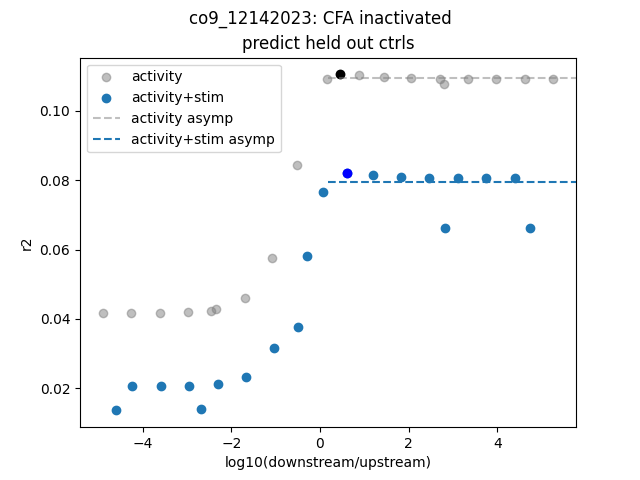

In [245]:
fig, ax = plt.subplots()
ax.scatter(ctop_c_ratio, ctop_c_r2, label='activity', color='gray', alpha=.5)
ax.scatter(ctop_sw_ratio, ctop_sw_r2, label='activity+stim')
#ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(c_pos_asymps, xmin=.5, xmax=1, linestyle='--', label='activity asymp', color='gray', alpha=.5)
#ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange', label=)
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:blue', label='activity+stim asymp')
ax.scatter(c_ratio[c_max_idx], c_r2[c_max_idx], color='black')
ax.scatter(sw_ratio[sw_max_idx], sw_r2[sw_max_idx], color='blue')
ax.set_ylabel('r2')
ax.set_xlabel('log10(downstream/upstream)')
fig.suptitle(f'{session_name}: {inact} inactivated')
ax.set_title('predict held out ctrls')
#ax.set_ylim(0,.35)
ax.legend()
#ax.set_xlim(-2,2)

In [246]:
ltop_c_ratio, ltop_c_r2, _ = get_top_models(c_ratio, l_r2, num_bins=20)
ltop_sw_ratio, ltop_sw_r2, _ = get_top_models(sw_ratio, lsw_r2, num_bins=20)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


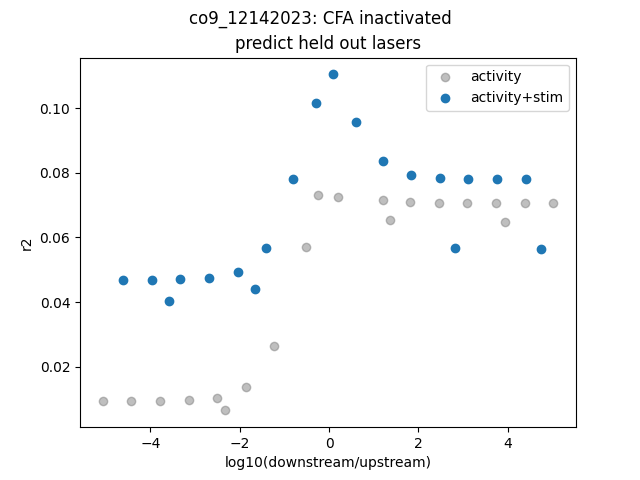

In [247]:
fig, ax = plt.subplots()
ax.scatter(ltop_c_ratio, ltop_c_r2, label='activity', color='gray', alpha=.5)
ax.scatter(ltop_sw_ratio, ltop_sw_r2, label='activity+stim')
#ax.scatter(c_ratio[c_max_idx], l_r2[c_max_idx], color='black')
#ax.scatter(sw_ratio[sw_max_idx], lsw_r2[sw_max_idx], color='blue')
fig.suptitle(f'{session_name}: {inact} inactivated')
ax.set_title('predict held out lasers')
ax.set_ylabel('r2')
ax.set_xlabel('log10(downstream/upstream)')
#ax.set_ylim(0,.35)
ax.legend()
#ax.set_xlim(-2,2)

In [248]:
coutput = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrl_20nlag_50post_50sw.pickle')
casymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrlasymps_20nlag_50post_50sw.pickle')

In [249]:
ctrl_c_r2 = []
ctrl_c_ratio = []
ctrl_l_r2=[]
ctrl_l_ratio=[]

ctrl_sw_r2 = []
ctrl_sw_ratio = []
ctrl_lsw_r2=[]
ctrl_lsw_ratio=[]


ctrl_regs=[]

ctrl_h_list =[]
ctrl_h_sw_list = []
cc_pos_asymps = casymps[sesh][0][0]
cc_neg_asymps = casymps[sesh][1][0]

csw_pos_asymps = casymps[sesh][0][1]
csw_neg_asymps = casymps[sesh][1][1]

for run in coutput[sesh]:
    ctrl_c=run[0]
    ctrl_sw=run[1]
    
    ctrl_regs.append(run[2][0])
    
    ctrl_h_list.append(ctrl_c[0])
    ctrl_l_ratio.append(ctrl_c[1])
    ctrl_c_ratio.append(ctrl_c[2])
    ctrl_l_r2.append(ctrl_c[3])
    ctrl_c_r2.append(ctrl_c[4])
    
    ctrl_h_sw_list.append(ctrl_sw[0])
    ctrl_lsw_ratio.append(ctrl_sw[1])
    ctrl_sw_ratio.append(ctrl_sw[2])
    ctrl_lsw_r2.append(ctrl_sw[3])
    ctrl_sw_r2.append(ctrl_sw[4])

In [250]:
ctop_cc_ratio, ctop_cc_r2, _ = get_top_models(ctrl_sw_ratio, ctrl_sw_r2, num_bins=20)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


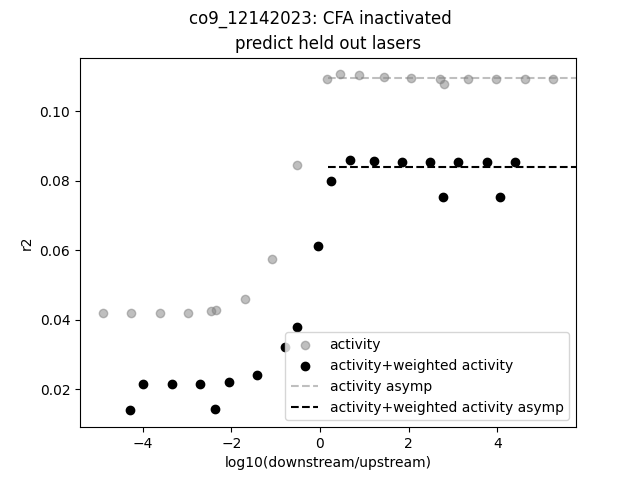

In [251]:
fig, ax = plt.subplots()
ax.scatter(ctop_c_ratio, ctop_c_r2, label='activity', color='gray', alpha=.5)
ax.scatter(ctop_cc_ratio, ctop_cc_r2, label='activity+weighted activity', color='black')
#ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(c_pos_asymps, xmin=.5, xmax=1, linestyle='--', label='activity asymp', color='gray', alpha=.5)
#ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange', label=)
ax.axhline(csw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='black', label='activity+weighted activity asymp')
ax.set_ylabel('r2')
fig.suptitle(f'{session_name}: {inact} inactivated')
ax.set_title('predict held out lasers')
ax.set_xlabel('log10(downstream/upstream)')
#ax.set_ylim(0,.35)
ax.legend()
#ax.set_xlim(-2,2)

# lets look at weights

In [252]:
percent_change_list=[]

h_col_list=[]
h_sw_col_list = []
good_c_ratio=[]
good_sw_ratio=[]

for idx in range(len(h_list)):
    h_ctrl_sw = ctrl_h_sw_list[idx]
    h_sw = h_sw_list[idx]
    if ctrl_sw_r2[idx] < sw_pos_asymps - .05:
        continue
    if sw_r2[idx] < sw_pos_asymps - .05:
        continue
    good_c_ratio.append(ctrl_c_ratio[idx])
    good_sw_ratio.append(sw_ratio[idx])
    #print('good!')
    h_col = collapse_h(h_ctrl_sw, nlags=20)
    h_sw_col = collapse_h(h_sw, nlags=20)
    
    h_col_list.append(h_col)
    h_sw_col_list.append(h_sw_col)
    
    percent_change_list.append(h_sw_col/h_col * 100)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0.98, 'co9_12142023: CFA inactivated')

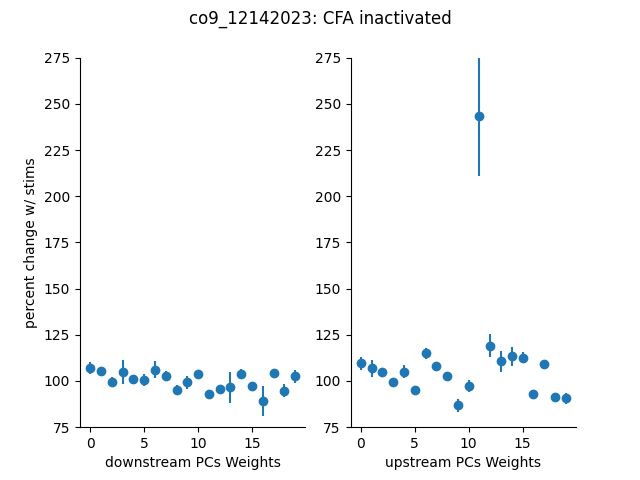

In [254]:
percent_change = np.array(percent_change_list)
stdz = np.std(percent_change, axis=0)
cfa_percent_change = percent_change[:,:20]
thal_percent_change = percent_change[:,20:]

cfa_std = stdz[:20]
thal_std = stdz[20:]

fig, ax = plt.subplots(ncols=2)
ax[0].errorbar(np.arange(20), np.average(cfa_percent_change, axis=0), yerr=cfa_std, fmt="o")
ax[1].errorbar(np.arange(20), np.average(thal_percent_change, axis=0), yerr=thal_std, fmt="o")
ax[0].set_ylabel('percent change w/ stims')
ax[0].set_xlabel('downstream PCs Weights')
ax[1].set_xlabel('upstream PCs Weights') 

ax[0].set_ylim(75, 275)
ax[1].set_ylim(75, 275)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
fig.suptitle(f'{session_name}: {inact} inactivated')
#fig.suptitle('percent change to weights when including stims when fitting')
#fig.savefig('../results/grant_2024/weight change.pdf')

In [255]:
percent_change_list=[]

h_col_list=[]
h_sw_col_list = []
good_c_ratio=[]
good_sw_ratio=[]

for idx in range(len(h_list)):
    h_ctrl_sw = ctrl_h_sw_list[idx]
    h_sw = h_sw_list[idx]
    if ctrl_sw_r2[idx] < sw_pos_asymps - .05:
        continue
    if sw_r2[idx] < sw_pos_asymps - .05:
        continue
    good_c_ratio.append(ctrl_c_ratio[idx])
    good_sw_ratio.append(sw_ratio[idx])
    #print('good!')
    h_col = collapse_h_lags(h_ctrl_sw, nlags=20)
    h_sw_col = collapse_h_lags(h_sw, nlags=20)
    
    h_col_list.append(h_col)
    h_sw_col_list.append(h_sw_col)
    
    percent_change_list.append(h_sw_col/h_col * 100)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0, 0.5, 'percent change w/ stims')

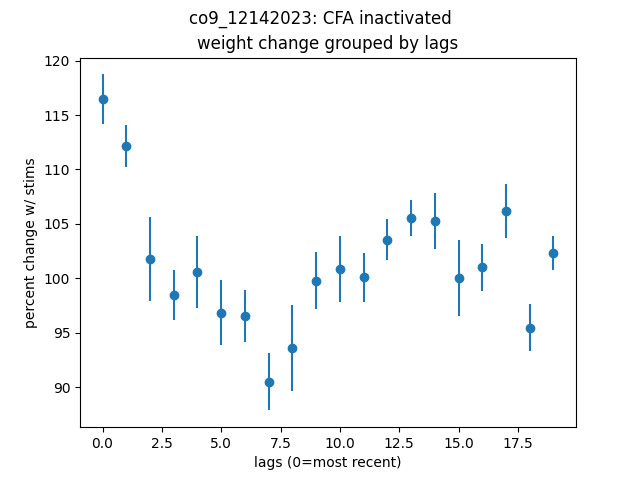

In [256]:
percent_change = np.array(percent_change_list)
stdz = np.std(percent_change, axis=0)

fig, ax = plt.subplots()
ax.errorbar(np.arange(20), np.flip(np.average(percent_change, axis=0)), yerr=stdz, fmt="o")
fig.suptitle(f'{session_name}: {inact} inactivated')
ax.set_title('weight change grouped by lags')
ax.set_xlabel('lags (0=most recent)')

ax.set_ylabel('percent change w/ stims')

In [216]:
format_check,_ = format_data_ar(check, nlags=5)

In [218]:
format_check.shape

(15, 10)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


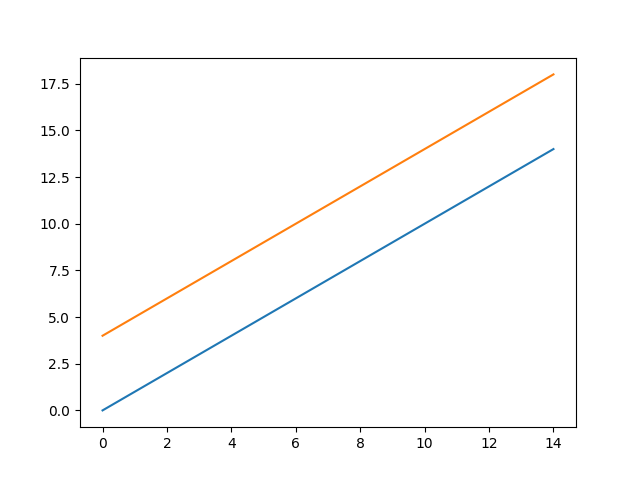

In [227]:
fig, ax = plt.subplots()
ax.plot(format_check[:,0])
ax.plot(format_check[:,8])

In [209]:
two.shape

(20,)

In [180]:
sorted_h_sw = [x for _, x in sorted(zip(good_sw_ratio, h_sw_col_list))]
sorted_h = [x for _, x in sorted(zip(good_c_ratio, h_col_list))]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


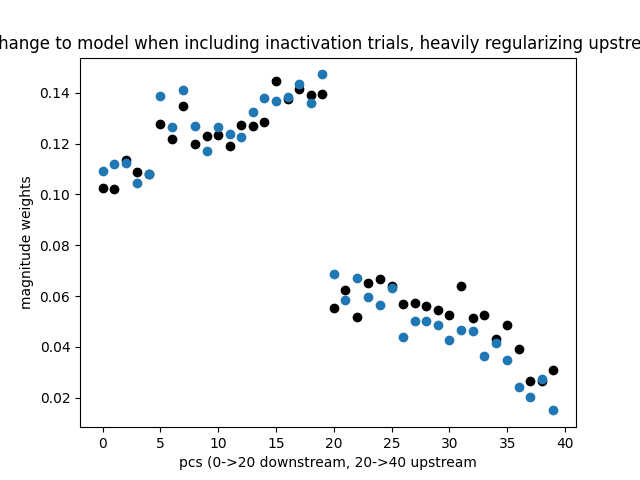

In [186]:
fig, ax = plt.subplots()
ax.set_title('change to model when including inactivation trials, heavily regularizing upstream')
ax.set_ylabel('magnitude weights')
ax.set_xlabel('pcs (0->20 downstream, 20->40 upstream')
ax.scatter(np.arange(len(sorted_h[40])), sorted_h[40], c='black')
ax.scatter(np.arange(len(sorted_h_sw[40])), sorted_h_sw[40])

In [22]:
output = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSW_20nlag_10post_100sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSWasymps_20nlag_10post_100sw.pickle')

In [39]:
c_r2 = []
c_ratio = []
l_r2=[]
l_ratio=[]

sw_r2 = []
sw_ratio = []
lsw_r2=[]
lsw_ratio=[]

h_list =[]
h_sw_list = []

sesh=4

regs=[]

c_pos_asymps = asymps[sesh][0][0]
c_neg_asymps = asymps[sesh][1][0]

sw_pos_asymps = asymps[sesh][0][1]
sw_neg_asymps = asymps[sesh][1][1]

print(output[sesh][0][2][1])
print(output[sesh][0][2][2])
for run in output[sesh]:
    c=run[0]
    sw=run[1]
    

    
    regs.append(run[2][0])
    h_list.append(c[0])
    l_ratio.append(c[1])
    #c_ratio.append(c[2])
   
    d, u = session.weights_per_region(h_list[-1], nlags=20, num_region1=20)
    c_ratio.append(np.log10(d/u))
    
    
    l_r2.append(c[3])
    c_r2.append(c[4])
    
    h_sw_list.append(sw[0])
    lsw_ratio.append(sw[1])
    
    d, u = session.weights_per_region(h_sw_list[-1], nlags=20, num_region1=20)
    sw_ratio.append(np.log10(d/u))
    #sw_ratio.append(sw[2])
    lsw_r2.append(sw[3])
    sw_r2.append(sw[4])

co7_12082023
CFA


In [40]:
max_idx = np.argmax(c_r2)
print(regs[max_idx])

(7196.856730011528, 7196.856730011528)


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


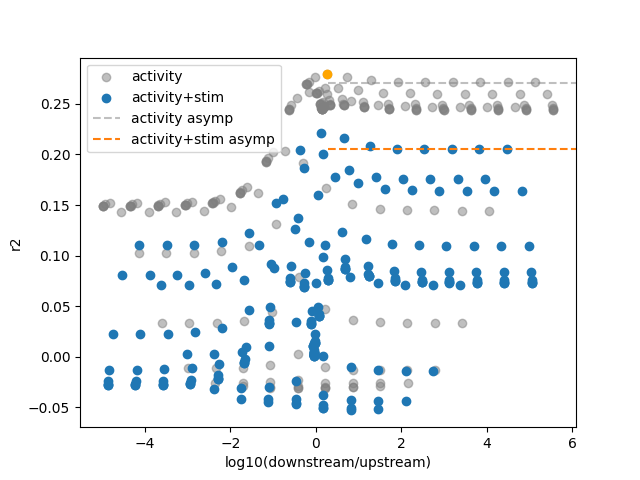

In [41]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, c_r2, label='activity', color='gray', alpha=.5)
ax.scatter(sw_ratio, sw_r2, label='activity+stim')
#ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(c_pos_asymps, xmin=.5, xmax=1, linestyle='--', label='activity asymp', color='gray', alpha=.5)
#ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange', label=)
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:orange', label='activity+stim asymp')
ax.scatter(c_ratio[max_idx], c_r2[max_idx], color='orange')
ax.set_ylabel('r2')
ax.set_xlabel('log10(downstream/upstream)')
#ax.set_ylim(0,.35)
ax.legend()
#ax.set_xlim(-2,2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


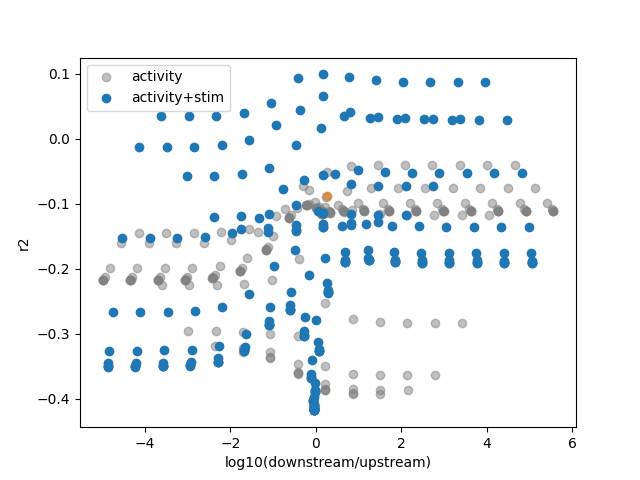

In [42]:

fig, ax = plt.subplots()
ax.scatter(c_ratio, l_r2, label='activity', color='gray', alpha=.5)
ax.scatter(sw_ratio, lsw_r2, label='activity+stim')
#ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
#ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange', label=)
ax.scatter(c_ratio[max_idx], l_r2[max_idx], color='tab:orange', alpha=.5)
ax.set_ylabel('r2')
ax.set_xlabel('log10(downstream/upstream)')
#ax.set_ylim(0,.35)
ax.legend()
#ax.set_xlim(-2,2)

In [16]:
session_path = '../data/co/co10/co10_01252024'
session = MPOptoClass(session_path)

love


In [135]:
output = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSWCombine_20nlag_50post_50sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSWasympsCombine_20nlag_50post_50sw.pickle')

In [140]:
c_r2 = []
c_ratio = []

sw_r2 = []
sw_ratio = []

h_list =[]
h_sw_list = []

sesh=1

regs=[]

c_pos_asymps = asymps[sesh][0][0]
c_neg_asymps = asymps[sesh][1][0]

sw_pos_asymps = asymps[sesh][0][1]
sw_neg_asymps = asymps[sesh][1][1]

print(output[sesh][0][2][1])
print(output[sesh][0][2][2])
for run in output[sesh]:
    c=run[0]
    sw=run[1]
    

    
    regs.append(run[2][0])
    h_list.append(c[0])
    d, u = session.weights_per_region(h_list[-1], nlags=20, num_region1=20)
    c_ratio.append(np.log10(d/u))
    c_r2.append(c[1])
    
    h_sw_list.append(sw[0])
    d, u = session.weights_per_region(h_sw_list[-1], nlags=20, num_region1=20)
    sw_ratio.append(np.log10(d/u))
    sw_r2.append(sw[1])

co12_02132024
RFA


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


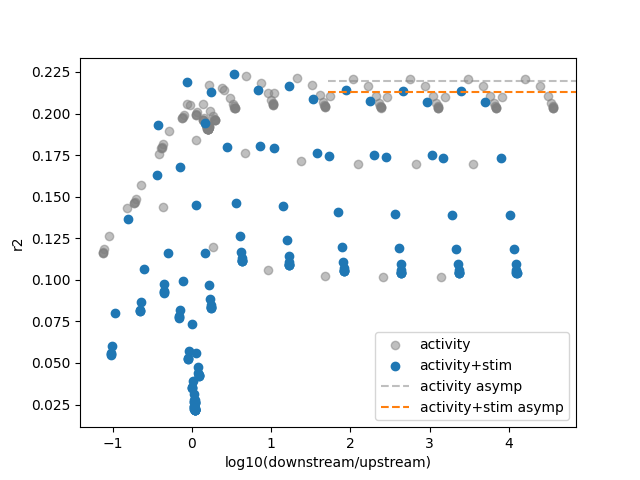

In [141]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, c_r2, label='activity', color='gray', alpha=.5)
ax.scatter(sw_ratio, sw_r2, label='activity+stim')
#ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(c_pos_asymps, xmin=.5, xmax=1, linestyle='--', label='activity asymp', color='gray', alpha=.5)
#ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange', label=)
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:orange', label='activity+stim asymp')
#ax.scatter(c_ratio[max_idx], c_r2[max_idx], color='orange')
ax.set_ylabel('r2')
ax.set_xlabel('log10(downstream/upstream)')
#ax.set_ylim(0,.35)
ax.legend()
#ax.set_xlim(-2,2)

In [3]:
output = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsLaser_20nlag_50post.pickle') 
asymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsLaserasymps_20nlag_50post.pickle')

In [20]:
c_r2 = []
c_ratio = []

h_list =[]

sesh=6

regs=[]

pos_asymps = asymps[sesh][0]
neg_asymps = asymps[sesh][1]

print(output[sesh][0][1][1])
print(output[sesh][0][1][2])
for run in output[sesh]:
    c=run[0]
    
    regs.append(run[1][0])
    h_list.append(c[0])
    d, u = session.weights_per_region(h_list[-1], nlags=20, num_region1=20)
    c_ratio.append(np.log10(d/u))
    c_r2.append(c[1])

co9_12152023
CFA


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


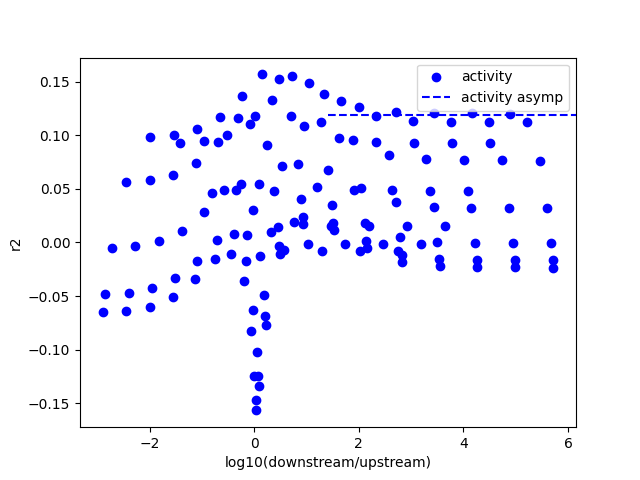

In [21]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, c_r2, label='activity', color='blue')
ax.axhline(pos_asymps, xmin=.5, xmax=1, linestyle='--', label='activity asymp', color='blue')
ax.set_ylabel('r2')
ax.set_xlabel('log10(downstream/upstream)')
#ax.set_ylim(0,.35)
ax.legend()
#ax.set_xlim(-2,2)

In [257]:
session_path = '../data/to/to3/to3_06052024'
session = MPOptoClass(session_path)

masking THAL, 300<x<1000
love


In [293]:
laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre=100, post=50, only_climb=True)
if session.num_powers ==5:
    power_mask = session.getPowers(bounds = laser_bounds, num_powers=5, pre, post)
    power_mask = np.logical_or(power_mask == 2, power_mask==5)
    laser_bounds 

5

In [261]:
output = pload('/home/diya/Documents/mp_opto/picklejar/toSweepRegsSW_20nlag_50post_50sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/toSweepRegsSWasymps_20nlag_50post_50sw.pickle')

In [299]:
c_r2 = []
c_ratio = []
l_r2=[]
l_ratio=[]

sw_r2 = []
sw_ratio = []
lsw_r2=[]
lsw_ratio=[]

h_list =[]
h_sw_list = []

sesh=5

regs=[]

c_pos_asymps = asymps[sesh][0][0]
c_neg_asymps = asymps[sesh][1][0]

sw_pos_asymps = asymps[sesh][0][1]
sw_neg_asymps = asymps[sesh][1][1]

session_name = output[sesh][0][2][1]
inact = output[sesh][0][2][2]
for run in output[sesh]:
    c=run[0]
    sw=run[1]
    

    
    regs.append(run[2][0])
    h_list.append(c[0])
    l_ratio.append(c[1])
    #c_ratio.append(c[2])
   
    d, u = session.weights_per_region(h_list[-1], nlags=20, num_region1=20)
    c_ratio.append(np.log10(d/u))
    
    
    l_r2.append(c[3])
    c_r2.append(c[4])
    
    h_sw_list.append(sw[0])
    lsw_ratio.append(sw[1])
    
    d, u = session.weights_per_region(h_sw_list[-1], nlags=20, num_region1=20)
    sw_ratio.append(np.log10(d/u))
    #sw_ratio.append(sw[2])
    lsw_r2.append(sw[3])
    sw_r2.append(sw[4])

In [300]:
ctop_c_ratio, ctop_c_r2, _ = get_top_models(c_ratio, c_r2, num_bins=20)
ctop_sw_ratio, ctop_sw_r2, _ = get_top_models(sw_ratio, sw_r2, num_bins=20)

In [301]:
c_max_idx = np.argmax(c_r2)
sw_max_idx = np.argmax(sw_r2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


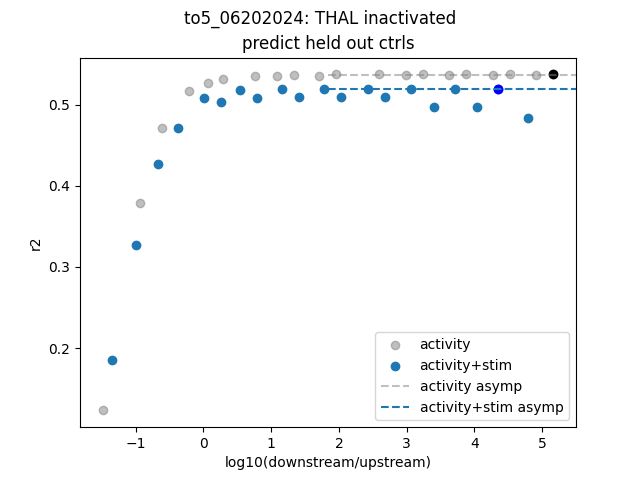

In [302]:
fig, ax = plt.subplots()
ax.scatter(ctop_c_ratio, ctop_c_r2, label='activity', color='gray', alpha=.5)
ax.scatter(ctop_sw_ratio, ctop_sw_r2, label='activity+stim')
#ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(c_pos_asymps, xmin=.5, xmax=1, linestyle='--', label='activity asymp', color='gray', alpha=.5)
#ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange', label=)
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:blue', label='activity+stim asymp')
ax.scatter(c_ratio[c_max_idx], c_r2[c_max_idx], color='black')
ax.scatter(sw_ratio[sw_max_idx], sw_r2[sw_max_idx], color='blue')
ax.set_ylabel('r2')
ax.set_xlabel('log10(downstream/upstream)')
fig.suptitle(f'{session_name}: {inact} inactivated')
ax.set_title('predict held out ctrls')
#ax.set_ylim(0,.35)
ax.legend()
#ax.set_xlim(-2,2)

In [303]:
ltop_c_ratio, ltop_c_r2, _ = get_top_models(c_ratio, l_r2, num_bins=20)
ltop_sw_ratio, ltop_sw_r2, _ = get_top_models(sw_ratio, lsw_r2, num_bins=20)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


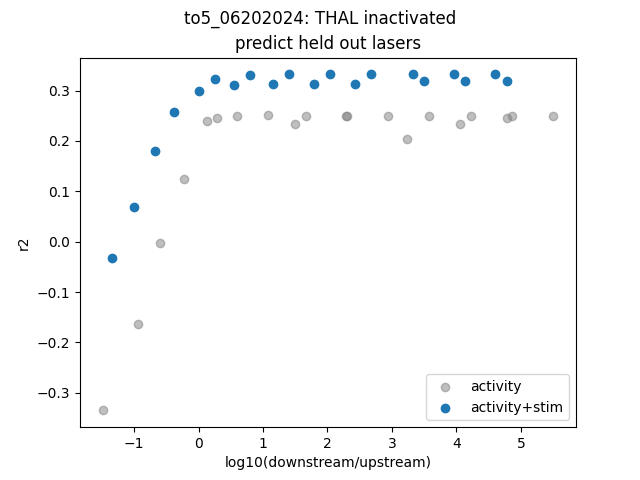

In [304]:
fig, ax = plt.subplots()
ax.scatter(ltop_c_ratio, ltop_c_r2, label='activity', color='gray', alpha=.5)
ax.scatter(ltop_sw_ratio, ltop_sw_r2, label='activity+stim')
#ax.scatter(c_ratio[c_max_idx], l_r2[c_max_idx], color='black')
#ax.scatter(sw_ratio[sw_max_idx], lsw_r2[sw_max_idx], color='blue')
fig.suptitle(f'{session_name}: {inact} inactivated')
ax.set_title('predict held out lasers')
ax.set_ylabel('r2')
ax.set_xlabel('log10(downstream/upstream)')
#ax.set_ylim(0,.35)
ax.legend()
#ax.set_xlim(-2,2)

In [259]:
c_r2 = []
c_ratio = []
l_r2=[]
l_ratio=[]

sw_r2 = []
sw_ratio = []
lsw_r2=[]
lsw_ratio=[]

h_list =[]
h_sw_list = []

regs=[]
sesh=7

c_pos_asymps = asymps[sesh][0][0]
c_neg_asymps = asymps[sesh][1][0]

sw_pos_asymps = asymps[sesh][0][1]
sw_neg_asymps = asymps[sesh][1][1]

print(output[sesh][0][2][1])
for run in output[sesh]:
    c=run[0]
    sw=run[1]
    
    
    regs.append(run[2][0])
    h_list.append(c[0])
    l_ratio.append(c[1])
    c_ratio.append(c[2])
    l_r2.append(c[3])
    c_r2.append(c[4])
    
    h_sw_list.append(sw[0])
    lsw_ratio.append(sw[1])
    sw_ratio.append(sw[2])
    lsw_r2.append(sw[3])
    sw_r2.append(sw[4])

to3_06042024


In [305]:
ctop_c_ratio, ctop_c_r2, _ = get_top_models(c_ratio, c_r2, num_bins=20)
ctop_sw_ratio, ctop_sw_r2, _ = get_top_models(sw_ratio, sw_r2, num_bins=20)

In [306]:
c_max_idx = np.argmax(c_r2)
sw_max_idx = np.argmax(sw_r2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


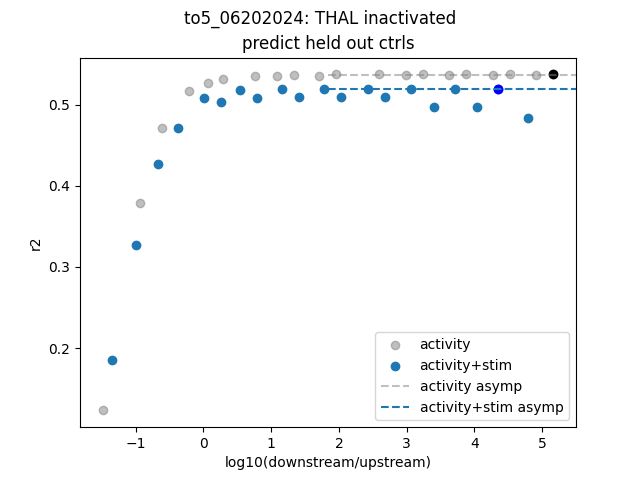

In [307]:
fig, ax = plt.subplots()
ax.scatter(ctop_c_ratio, ctop_c_r2, label='activity', color='gray', alpha=.5)
ax.scatter(ctop_sw_ratio, ctop_sw_r2, label='activity+stim')
#ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(c_pos_asymps, xmin=.5, xmax=1, linestyle='--', label='activity asymp', color='gray', alpha=.5)
#ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange', label=)
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:blue', label='activity+stim asymp')
ax.scatter(c_ratio[c_max_idx], c_r2[c_max_idx], color='black')
ax.scatter(sw_ratio[sw_max_idx], sw_r2[sw_max_idx], color='blue')
ax.set_ylabel('r2')
ax.set_xlabel('log10(downstream/upstream)')
fig.suptitle(f'{session_name}: {inact} inactivated')
ax.set_title('predict held out ctrls')
#ax.set_ylim(0,.35)
ax.legend()
#ax.set_xlim(-2,2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


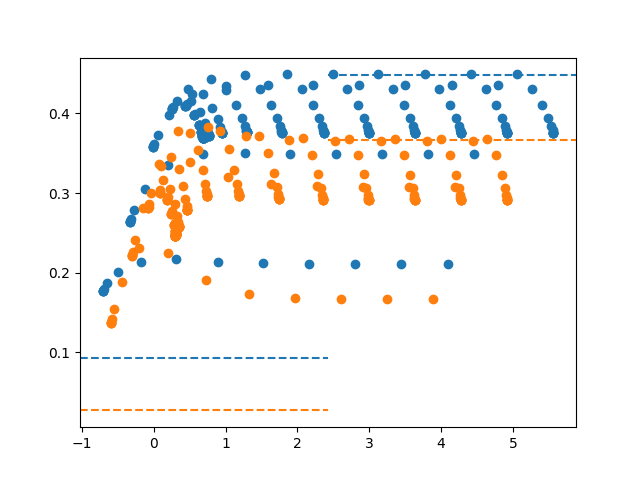

In [260]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, c_r2)
ax.scatter(sw_ratio, sw_r2)
ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(c_pos_asymps, xmin=.5, xmax=1, linestyle='--')
ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange')
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:orange')
#ax.set_ylim(0,.35)
#ax.set_xlim(-2,2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


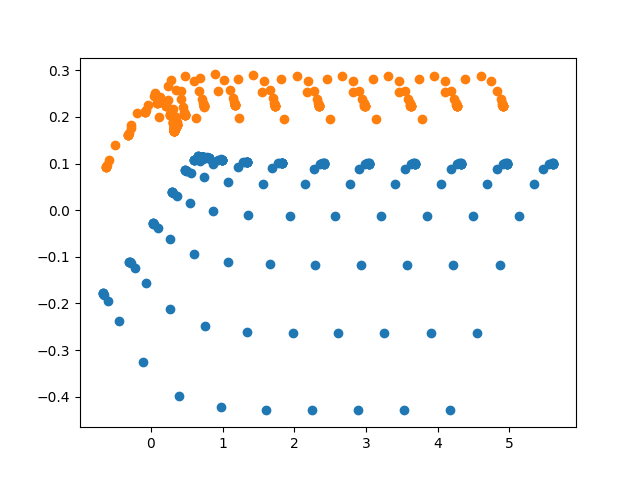

In [106]:
fig, ax = plt.subplots()
ax.scatter(l_ratio, l_r2, color='tab:blue')
ax.scatter(lsw_ratio, lsw_r2, color='tab:orange')
#ax.set_ylim(0,.25)
#ax.set_xlim(-2,2)

In [41]:
coutput = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrl_20nlag_50post_25sw.pickle')
casymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrlasymps_20nlag_50post_25sw.pickle')

In [42]:
ctrl_c_r2 = []
ctrl_c_ratio = []
ctrl_l_r2=[]
ctrl_l_ratio=[]

ctrl_sw_r2 = []
ctrl_sw_ratio = []
ctrl_lsw_r2=[]
ctrl_lsw_ratio=[]


ctrl_regs=[]

ctrl_h_list =[]
ctrl_h_sw_list = []
cc_pos_asymps = casymps[sesh][0][0]
cc_neg_asymps = casymps[sesh][1][0]

csw_pos_asymps = casymps[sesh][0][1]
csw_neg_asymps = casymps[sesh][1][1]

for run in coutput[sesh]:
    ctrl_c=run[0]
    ctrl_sw=run[1]
    
    ctrl_regs.append(run[2][0])
    
    ctrl_h_list.append(ctrl_c[0])
    ctrl_l_ratio.append(ctrl_c[1])
    ctrl_c_ratio.append(ctrl_c[2])
    ctrl_l_r2.append(ctrl_c[3])
    ctrl_c_r2.append(ctrl_c[4])
    
    ctrl_h_sw_list.append(ctrl_sw[0])
    ctrl_lsw_ratio.append(ctrl_sw[1])
    ctrl_sw_ratio.append(ctrl_sw[2])
    ctrl_lsw_r2.append(ctrl_sw[3])
    ctrl_sw_r2.append(ctrl_sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

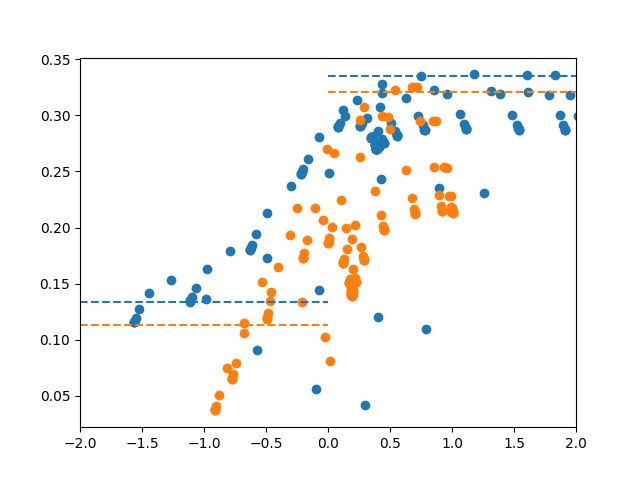

In [43]:
fig, ax = plt.subplots()
ax.scatter(ctrl_c_ratio, ctrl_c_r2)
ax.scatter(ctrl_sw_ratio, ctrl_sw_r2)
ax.axhline(cc_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(cc_pos_asymps, xmin=.5, xmax=1, linestyle='--')
ax.axhline(csw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange')
ax.axhline(csw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:orange')
#ax.set_ylim(0,.35)
ax.set_xlim(-2,2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

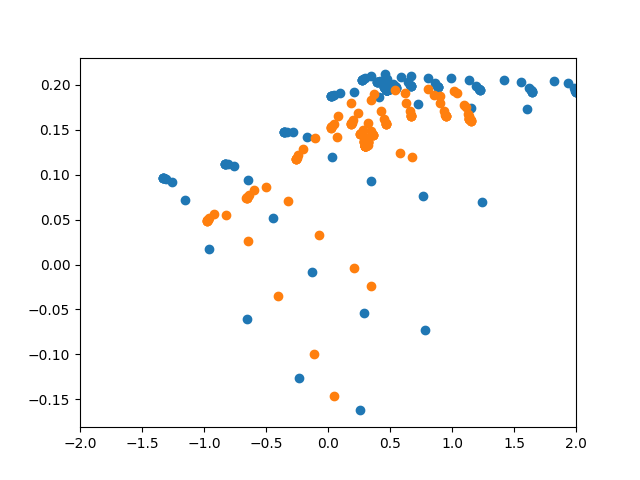

In [64]:
fig, ax = plt.subplots()
ax.scatter(ctrl_l_ratio, ctrl_l_r2)
ax.scatter(ctrl_lsw_ratio, ctrl_lsw_r2)
#ax.set_ylim(0,.2)
ax.set_xlim(-2,2)
#ax.axhline(neg_asymps, xmin=0, xmax=.5, linestyle='--')
#ax.axhline(pos_asymps, xmin=.5, xmax=1, linestyle='--')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


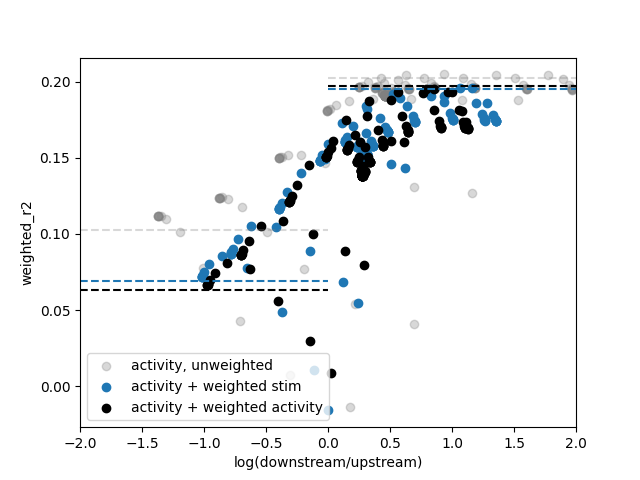

In [65]:
fig, ax = plt.subplots()
ax.scatter(ctrl_c_ratio, ctrl_c_r2, color='gray', alpha=.3, label='activity, unweighted')
ax.scatter(sw_ratio, sw_r2, color='tab:blue', label='activity + weighted stim')
ax.scatter(ctrl_sw_ratio, ctrl_sw_r2, color='black', label='activity + weighted activity')
ax.axhline(cc_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='gray', alpha=.3)
ax.axhline(cc_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='gray', alpha=.3)
ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:blue')
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:blue')
ax.axhline(csw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='black')
ax.axhline(csw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='black')
#ax.set_ylim(-.05,.35)
ax.set_xlim(-2,2)
ax.set_xlabel('log(downstream/upstream)')
ax.set_ylabel('weighted_r2')
ax.legend()

# lets look at weights

In [122]:
percent_change_list=[]

h_col_list=[]
h_sw_col_list = []
good_c_ratio=[]
good_sw_ratio=[]

for idx in range(len(h_list)):
    h_ctrl_sw = ctrl_h_sw_list[idx]
    h_sw = h_sw_list[idx]
    if ctrl_sw_r2[idx] < 0.25:
        continue
    if sw_r2[idx] < 0.25:
        continue
    good_c_ratio.append(ctrl_c_ratio[idx])
    good_sw_ratio.append(sw_ratio[idx])
    #print('good!')
    h_col = collapse_h(h_ctrl_sw, nlags=20)
    h_sw_col = collapse_h(h_sw, nlags=20)
    
    h_col_list.append(h_col)
    h_sw_col_list.append(h_sw_col)
    
    percent_change_list.append(h_sw_col/h_col * 100)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


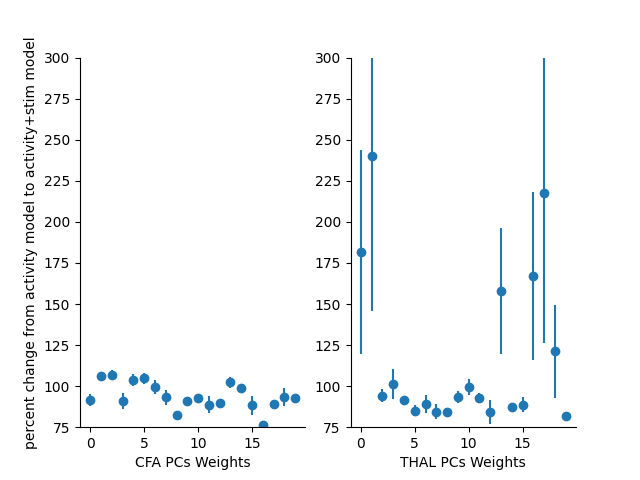

In [126]:
percent_change = np.array(percent_change_list)
stdz = np.std(percent_change, axis=0)
cfa_percent_change = percent_change[:,:20]
thal_percent_change = percent_change[:,20:]

cfa_std = stdz[:20]
thal_std = stdz[20:]

fig, ax = plt.subplots(ncols=2)
ax[0].errorbar(np.arange(20), np.average(cfa_percent_change, axis=0), yerr=cfa_std, fmt="o")
ax[1].errorbar(np.arange(20), np.average(thal_percent_change, axis=0), yerr=thal_std, fmt="o")
ax[0].set_ylabel('percent change from activity model to activity+stim model')
ax[0].set_xlabel('CFA PCs Weights')
ax[1].set_xlabel('THAL PCs Weights') 

ax[0].set_ylim(75, 300)
ax[1].set_ylim(75, 300)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
#fig.suptitle('percent change to weights when including stims when fitting')
#fig.savefig('../results/grant_2024/weight change.pdf')

In [129]:
output = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSW_20nlag_50post_50sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSWasymps_20nlag_50post_50sw.pickle')

In [130]:
c_r2 = []
c_ratio = []
l_r2=[]
l_ratio=[]

sw_r2 = []
sw_ratio = []
lsw_r2=[]
lsw_ratio=[]

h_list =[]
h_sw_list = []

sesh=1

regs=[]

c_pos_asymps = asymps[sesh][0][0]
c_neg_asymps = asymps[sesh][1][0]

sw_pos_asymps = asymps[sesh][0][1]
sw_neg_asymps = asymps[sesh][1][1]

for run in output[sesh]:
    c=run[0]
    sw=run[1]
    
    
    regs.append(run[2][0])
    h_list.append(c[0])
    l_ratio.append(c[1])
    c_ratio.append(c[2])
    l_r2.append(c[3])
    c_r2.append(c[4])
    
    h_sw_list.append(sw[0])
    lsw_ratio.append(sw[1])
    sw_ratio.append(sw[2])
    lsw_r2.append(sw[3])
    sw_r2.append(sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

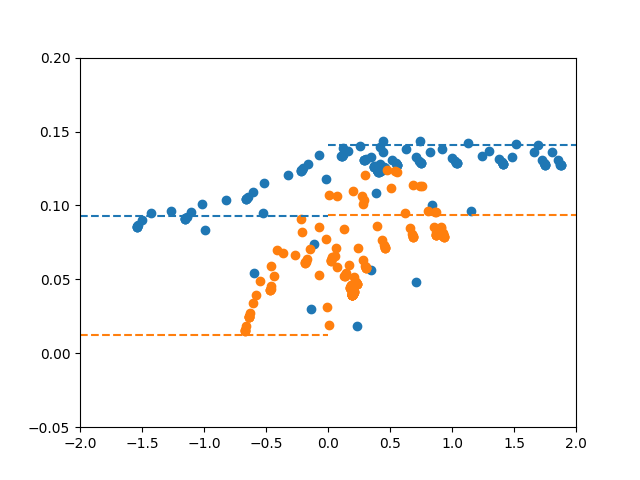

In [132]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, c_r2)
ax.scatter(sw_ratio, sw_r2)
ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(c_pos_asymps, xmin=.5, xmax=1, linestyle='--')
ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange')
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:orange')
ax.set_ylim(-.05,.2)
ax.set_xlim(-2,2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

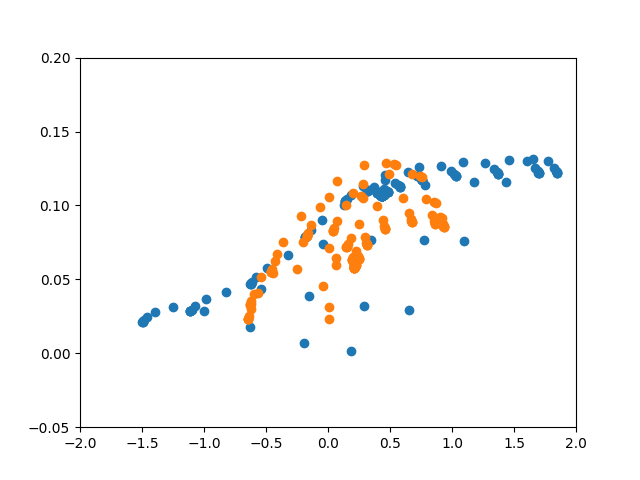

In [133]:
fig, ax = plt.subplots()
ax.scatter(l_ratio, l_r2)
ax.scatter(lsw_ratio, lsw_r2)
ax.set_ylim(-.05,.2)
ax.set_xlim(-2,2)

In [134]:
coutput = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrl_20nlag_50post_50sw.pickle')
casymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrlasymps_20nlag_50post_50sw.pickle')

In [135]:
ctrl_c_r2 = []
ctrl_c_ratio = []
ctrl_l_r2=[]
ctrl_l_ratio=[]

ctrl_sw_r2 = []
ctrl_sw_ratio = []
ctrl_lsw_r2=[]
ctrl_lsw_ratio=[]


ctrl_regs=[]

ctrl_h_list =[]
ctrl_h_sw_list = []
cc_pos_asymps = casymps[sesh][0][0]
cc_neg_asymps = casymps[sesh][1][0]

csw_pos_asymps = casymps[sesh][0][1]
csw_neg_asymps = casymps[sesh][1][1]

for run in coutput[sesh]:
    ctrl_c=run[0]
    ctrl_sw=run[1]
    
    ctrl_regs.append(run[2][0])
    
    ctrl_h_list.append(ctrl_c[0])
    ctrl_l_ratio.append(ctrl_c[1])
    ctrl_c_ratio.append(ctrl_c[2])
    ctrl_l_r2.append(ctrl_c[3])
    ctrl_c_r2.append(ctrl_c[4])
    
    ctrl_h_sw_list.append(ctrl_sw[0])
    ctrl_lsw_ratio.append(ctrl_sw[1])
    ctrl_sw_ratio.append(ctrl_sw[2])
    ctrl_lsw_r2.append(ctrl_sw[3])
    ctrl_sw_r2.append(ctrl_sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

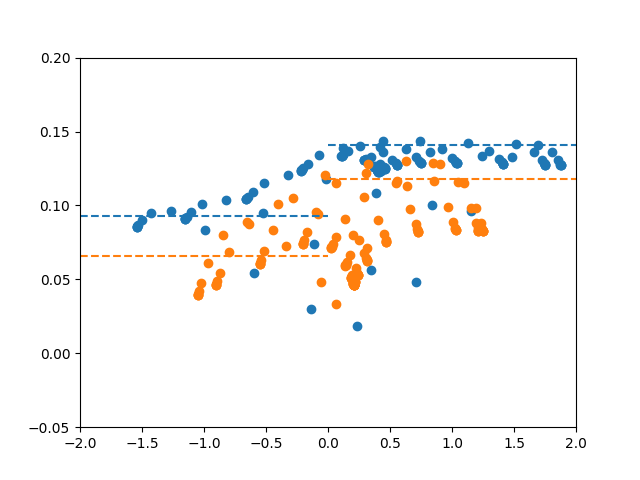

In [136]:
fig, ax = plt.subplots()
ax.scatter(ctrl_c_ratio, ctrl_c_r2)
ax.scatter(ctrl_sw_ratio, ctrl_sw_r2)
ax.axhline(cc_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(cc_pos_asymps, xmin=.5, xmax=1, linestyle='--')
ax.axhline(csw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange')
ax.axhline(csw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:orange')
ax.set_ylim(-.05,.2)
ax.set_xlim(-2,2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

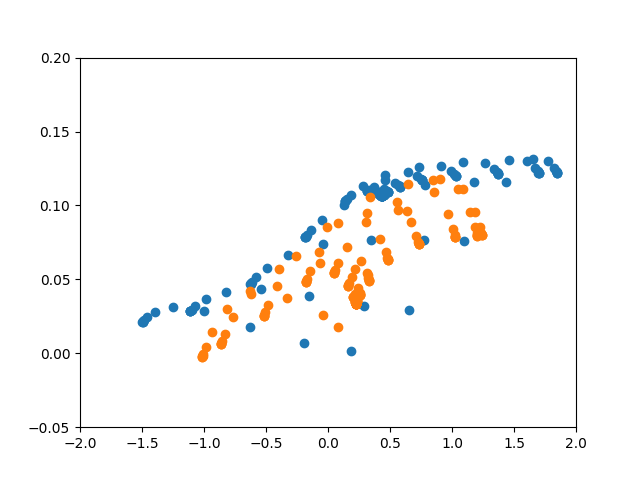

In [137]:
fig, ax = plt.subplots()
ax.scatter(ctrl_l_ratio, ctrl_l_r2)
ax.scatter(ctrl_lsw_ratio, ctrl_lsw_r2)
ax.set_ylim(-.05,.2)
ax.set_xlim(-2,2)
#ax.axhline(neg_asymps, xmin=0, xmax=.5, linestyle='--')
#ax.axhline(pos_asymps, xmin=.5, xmax=1, linestyle='--')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

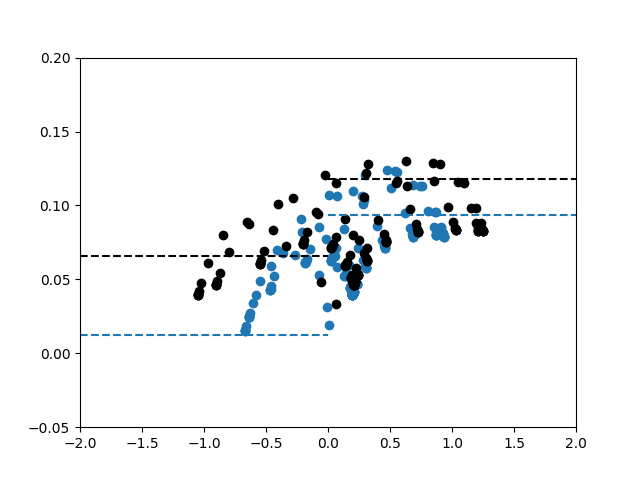

In [138]:
fig, ax = plt.subplots()
ax.scatter(sw_ratio, sw_r2, color='tab:blue')
ax.scatter(ctrl_sw_ratio, ctrl_sw_r2, color='black')
ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:blue')
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:blue')
ax.axhline(csw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='black')
ax.axhline(csw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='black')
ax.set_ylim(-.05,.2)
ax.set_xlim(-2,2)

# lets look at weights

In [157]:
percent_change_list=[]

h_col_list=[]
h_sw_col_list = []
good_c_ratio=[]
good_sw_ratio=[]

for idx in range(len(h_list)):
    h_ctrl_sw = ctrl_h_sw_list[idx]
    h_sw = h_sw_list[idx]
    if ctrl_sw_r2[idx] < 0.1:
        continue
    if sw_r2[idx] < 0.1:
        continue
    good_c_ratio.append(ctrl_c_ratio[idx])
    good_sw_ratio.append(sw_ratio[idx])
    #print('good!')
    h_col = collapse_h(h_ctrl_sw, nlags=20)
    h_sw_col = collapse_h(h_sw, nlags=20)
    
    h_col_list.append(h_col)
    h_sw_col_list.append(h_sw_col)
    
    percent_change_list.append(h_sw_col/h_col * 100)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


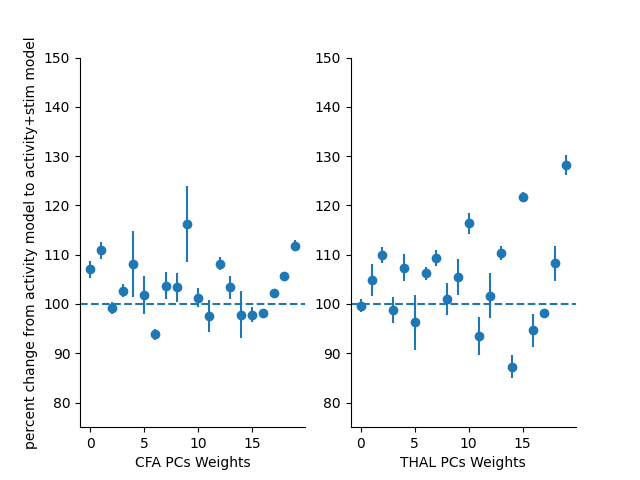

In [158]:
percent_change = np.array(percent_change_list)
stdz = np.std(percent_change, axis=0)
cfa_percent_change = percent_change[:,:20]
thal_percent_change = percent_change[:,20:]

cfa_std = stdz[:20]
thal_std = stdz[20:]

fig, ax = plt.subplots(ncols=2)
ax[0].errorbar(np.arange(20), np.average(cfa_percent_change, axis=0), yerr=cfa_std, fmt="o")
ax[1].errorbar(np.arange(20), np.average(thal_percent_change, axis=0), yerr=thal_std, fmt="o")
ax[0].set_ylabel('percent change from activity model to activity+stim model')
ax[0].set_xlabel('CFA PCs Weights')
ax[1].set_xlabel('THAL PCs Weights') 

ax[0].set_ylim(75, 150)
ax[1].set_ylim(75, 150)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].axhline(100, linestyle='--')
ax[0].axhline(100, linestyle='--')
#fig.suptitle('percent change to weights when including stims when fitting')
#fig.savefig('../results/grant_2024/weight change.pdf')

In [159]:
sorted_h_sw = [x for _, x in sorted(zip(good_sw_ratio, h_sw_col_list))]
sorted_h = [x for _, x in sorted(zip(good_c_ratio, h_col_list))]

119


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


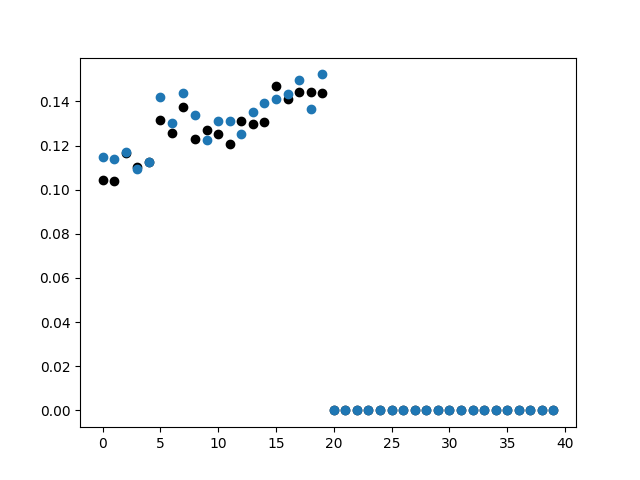

In [204]:
fig, ax = plt.subplots()
ax.scatter(np.arange(len(sorted_h[-5])), sorted_h[-5], c='black')
ax.scatter(np.arange(len(sorted_h_sw[-5])), sorted_h_sw[-5])
print(len(sorted_h))

In [197]:
session_path = '../data/to/to3/to3_06052024'
session = MPOptoClass(session_path)

masking THAL, 300<x<1000
love


In [201]:
laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre=0, post=50,only_climb=True)
climb_bounds = omitBoundInBounds(session.climbing_bounds, laser_bounds)
climb_bounds = omitBoundInBounds(climb_bounds, ctrl_bounds)
lasers = np.count_nonzero(bounds2Logical(laser_bounds))
climbs = np.count_nonzero(bounds2Logical(climb_bounds))

In [202]:
lasers/climbs

0.06314003607128664

# graveyard

In [77]:
output = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSW_20nlag_50post_25sw_skew.pickle')
#asymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSWSkewasymps_20nlag_50post_25sw.pickle')

In [79]:
c_r2 = []
c_ratio = []
l_r2=[]
l_ratio=[]

sw_r2 = []
sw_ratio = []
lsw_r2=[]
lsw_ratio=[]

h_list =[]
h_sw_list = []

sesh=0

regs=[]

#pos_asymps = asymps[sesh][0][0]
#neg_asymps = asymps[sesh][1][0]

for run in output[sesh]:
    c=run[0]
    sw=run[1]
    
    
    regs.append(run[2][0])
    h_list.append(c[0])
    l_ratio.append(c[1])
    c_ratio.append(c[2])
    l_r2.append(c[3])
    c_r2.append(c[4])
    
    h_sw_list.append(sw[0])
    lsw_ratio.append(sw[1])
    sw_ratio.append(sw[2])
    lsw_r2.append(sw[3])
    sw_r2.append(sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


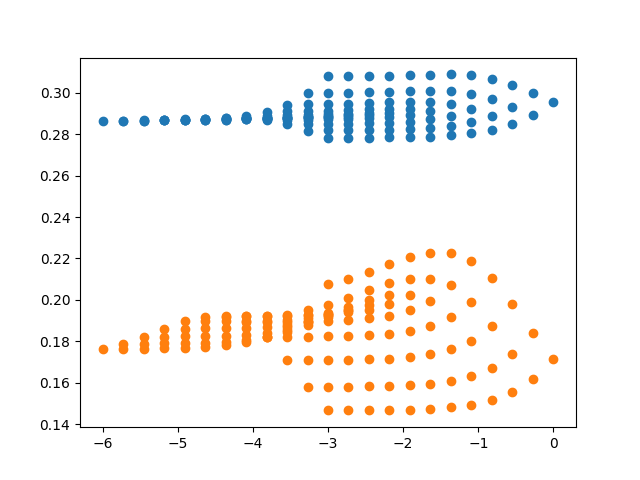

In [80]:
regs = np.array(regs)
reg_ratio = np.log10(np.array(regs[:,0] / regs[:,1]))
fig, ax = plt.subplots()
ax.scatter(reg_ratio, c_r2)
ax.scatter(reg_ratio, sw_r2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


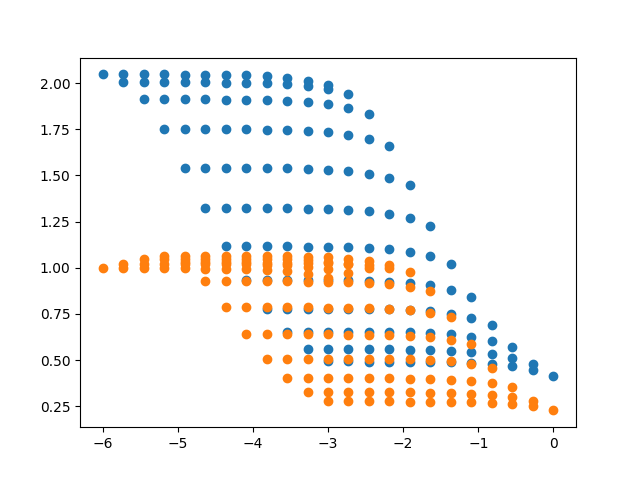

In [83]:
fig, ax = plt.subplots()
ax.scatter(reg_ratio, c_ratio)
ax.scatter(reg_ratio, sw_ratio)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(0.0, 2.5)

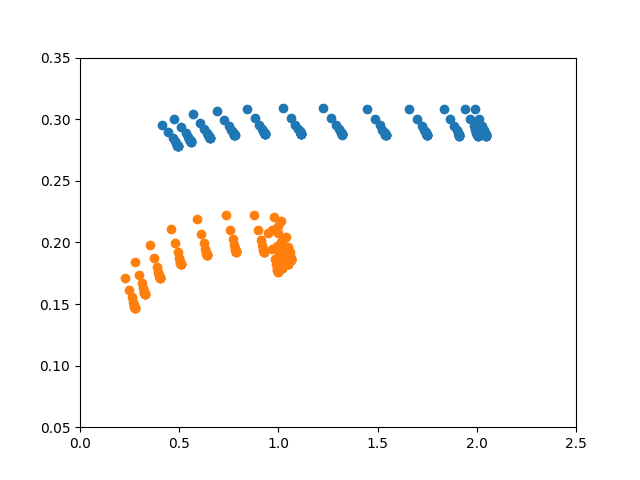

In [86]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, c_r2)
ax.scatter(sw_ratio, sw_r2)
#ax.axhline(neg_asymps, xmin=0, xmax=.5, linestyle='--')
#ax.axhline(pos_asymps, xmin=.5, xmax=1, linestyle='--')
ax.set_ylim(.05,.35)
ax.set_xlim(0,2.5)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

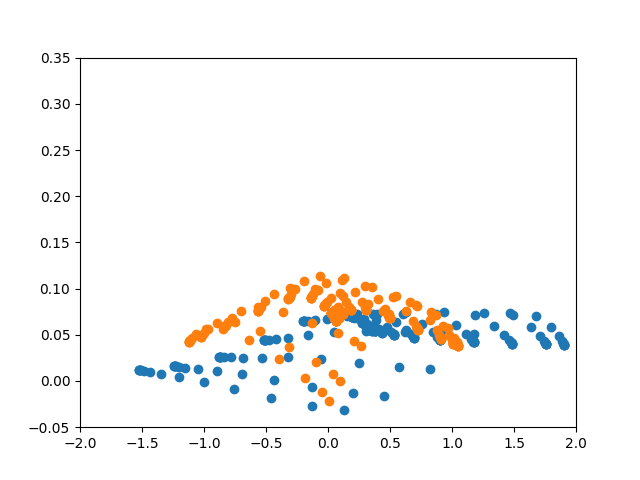

In [42]:
fig, ax = plt.subplots()
ax.scatter(l_ratio, l_r2)
ax.scatter(lsw_ratio, lsw_r2)
ax.set_ylim(-.05,.35)
ax.set_xlim(-2,2)

# graveyard

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


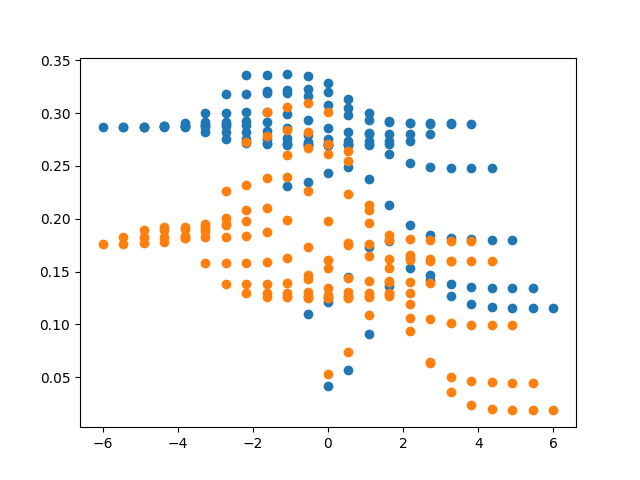

In [104]:
regs = np.array(regs)
reg_ratio = np.log10(np.array(regs[:,0] / regs[:,1]))
fig, ax = plt.subplots()
ax.scatter(reg_ratio, c_r2)
ax.scatter(reg_ratio, sw_r2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


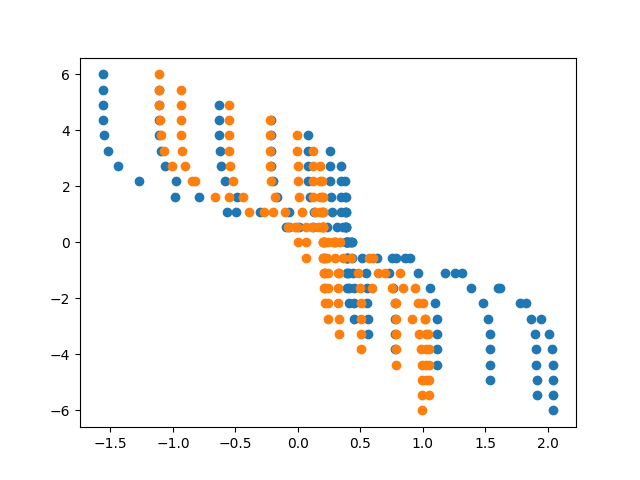

In [105]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, reg_ratio)
ax.scatter(sw_ratio, reg_ratio)

In [36]:
output = pload('/home/diya/Documents/mp_opto/picklejar/bulkSweepRegsSW_20nlag_50post_10sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/bulkSweepRegsSWasymps_20nlag_50post_10sw.pickle')

In [38]:
c_r2 = []
c_ratio = []
l_r2=[]
l_ratio=[]

sw_r2 = []
sw_ratio = []
lsw_r2=[]
lsw_ratio=[]

h_list =[]
h_sw_list = []

sesh=4

regs=[]

pos_asymps = asymps[sesh][0][0]
neg_asymps = asymps[sesh][1][0]

for run in output[sesh]:
    c=run[0]
    sw=run[1]
    
    
    regs.append(run[2][0])
    h_list.append(c[0])
    l_ratio.append(c[1])
    c_ratio.append(c[2])
    l_r2.append(c[3])
    c_r2.append(c[4])
    
    h_sw_list.append(sw[0])
    lsw_ratio.append(sw[1])
    sw_ratio.append(sw[2])
    lsw_r2.append(sw[3])
    sw_r2.append(sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


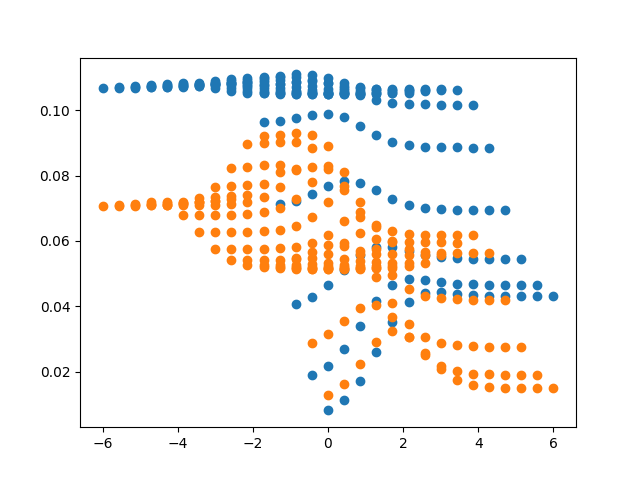

In [39]:
regs = np.array(regs)
reg_ratio = np.log10(np.array(regs[:,0] / regs[:,1]))
fig, ax = plt.subplots()
ax.scatter(reg_ratio, c_r2)
ax.scatter(reg_ratio, sw_r2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


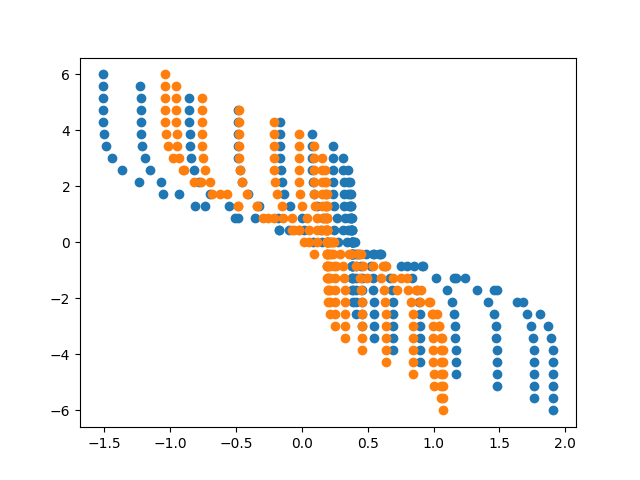

In [40]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, reg_ratio)
ax.scatter(sw_ratio, reg_ratio)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


NameError: name 'neg_asymps' is not defined

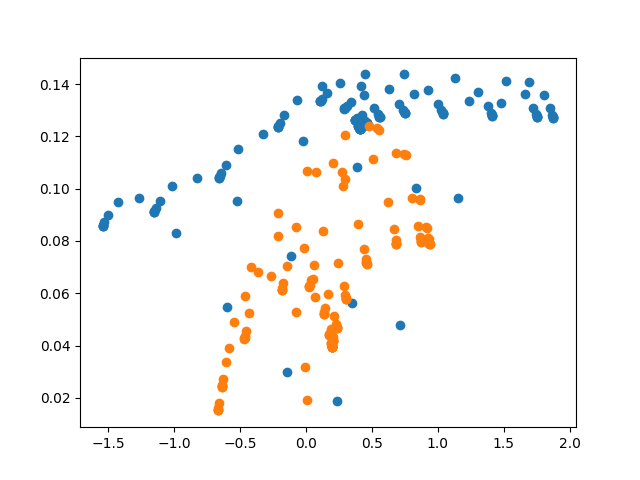

In [162]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, c_r2)
ax.scatter(sw_ratio, sw_r2)
ax.axhline(neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(pos_asymps, xmin=.5, xmax=1, linestyle='--')
ax.set_ylim(-.05,.2)
ax.set_xlim(-2,2)

In [214]:
output = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrl_20nlag_50post_5sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrlasymps_20nlag_50post_5sw.pickle')

In [215]:
c_r2 = []
c_ratio = []
l_r2=[]
l_ratio=[]

sw_r2 = []
sw_ratio = []
lsw_r2=[]
lsw_ratio=[]

h_list =[]
h_sw_list = []

sesh=0

regs=[]

c_pos_asymps = asymps[sesh][0][0]
c_neg_asymps = asymps[sesh][1][0]

sw_pos_asymps = asymps[sesh][0][1]
sw_neg_asymps = asymps[sesh][1][1]

for run in output[sesh]:
    c=run[0]
    sw=run[1]
    
    
    regs.append(run[2][0])
    h_list.append(c[0])
    l_ratio.append(c[1])
    c_ratio.append(c[2])
    l_r2.append(c[3])
    c_r2.append(c[4])
    
    h_sw_list.append(sw[0])
    lsw_ratio.append(sw[1])
    sw_ratio.append(sw[2])
    lsw_r2.append(sw[3])
    sw_r2.append(sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

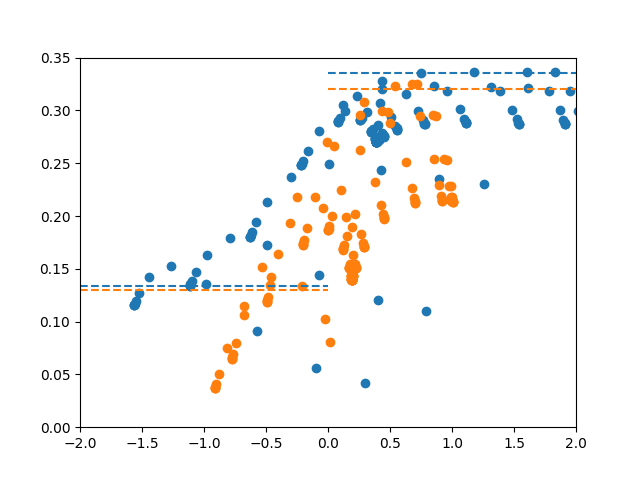

In [217]:
fig, ax = plt.subplots()
ax.scatter(c_ratio, c_r2)
ax.scatter(sw_ratio, sw_r2)
ax.axhline(c_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(c_pos_asymps, xmin=.5, xmax=1, linestyle='--')
ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange')
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:orange')
ax.set_ylim(0,.35)
ax.set_xlim(-2,2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

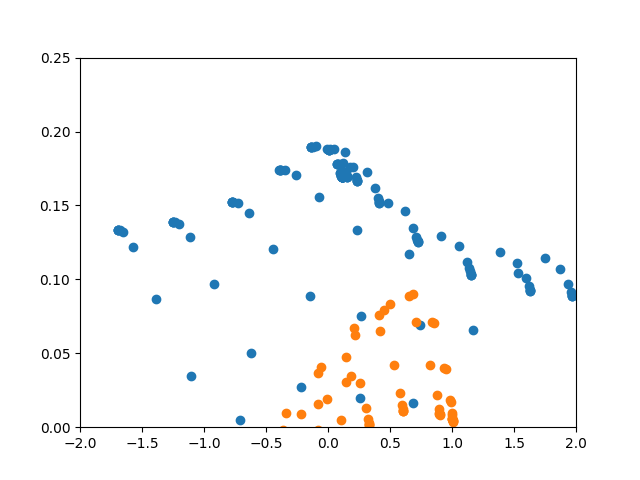

In [218]:
fig, ax = plt.subplots()
ax.scatter(l_ratio, l_r2)
ax.scatter(lsw_ratio, lsw_r2)
ax.set_ylim(0,.25)
ax.set_xlim(-2,2)

In [219]:
coutput = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrl_20nlag_50post_50sw.pickle')
casymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsCtrlasymps_20nlag_50post_50sw.pickle')

In [220]:
ctrl_c_r2 = []
ctrl_c_ratio = []
ctrl_l_r2=[]
ctrl_l_ratio=[]

ctrl_sw_r2 = []
ctrl_sw_ratio = []
ctrl_lsw_r2=[]
ctrl_lsw_ratio=[]


ctrl_regs=[]

ctrl_h_list =[]
ctrl_h_sw_list = []
cc_pos_asymps = casymps[sesh][0][0]
cc_neg_asymps = casymps[sesh][1][0]

csw_pos_asymps = casymps[sesh][0][1]
csw_neg_asymps = casymps[sesh][1][1]

for run in coutput[sesh]:
    ctrl_c=run[0]
    ctrl_sw=run[1]
    
    ctrl_regs.append(run[2][0])
    
    ctrl_h_list.append(ctrl_c[0])
    ctrl_l_ratio.append(ctrl_c[1])
    ctrl_c_ratio.append(ctrl_c[2])
    ctrl_l_r2.append(ctrl_c[3])
    ctrl_c_r2.append(ctrl_c[4])
    
    ctrl_h_sw_list.append(ctrl_sw[0])
    ctrl_lsw_ratio.append(ctrl_sw[1])
    ctrl_sw_ratio.append(ctrl_sw[2])
    ctrl_lsw_r2.append(ctrl_sw[3])
    ctrl_sw_r2.append(ctrl_sw[4])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

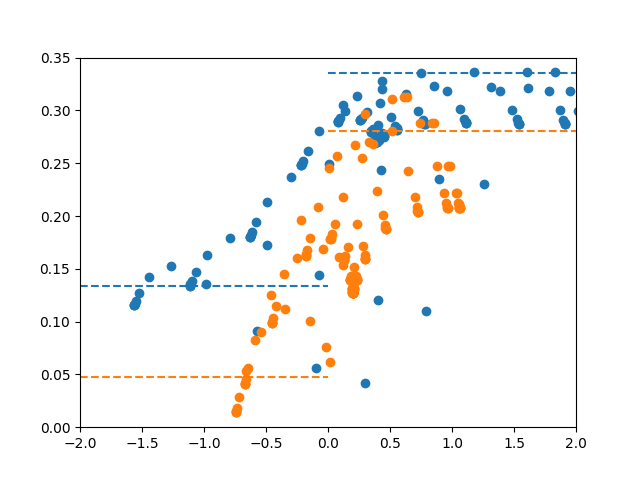

In [221]:
fig, ax = plt.subplots()
ax.scatter(ctrl_c_ratio, ctrl_c_r2)
ax.scatter(ctrl_sw_ratio, ctrl_sw_r2)
ax.axhline(cc_neg_asymps, xmin=0, xmax=.5, linestyle='--')
ax.axhline(cc_pos_asymps, xmin=.5, xmax=1, linestyle='--')
ax.axhline(csw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:orange')
ax.axhline(csw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:orange')
ax.set_ylim(0,.35)
ax.set_xlim(-2,2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

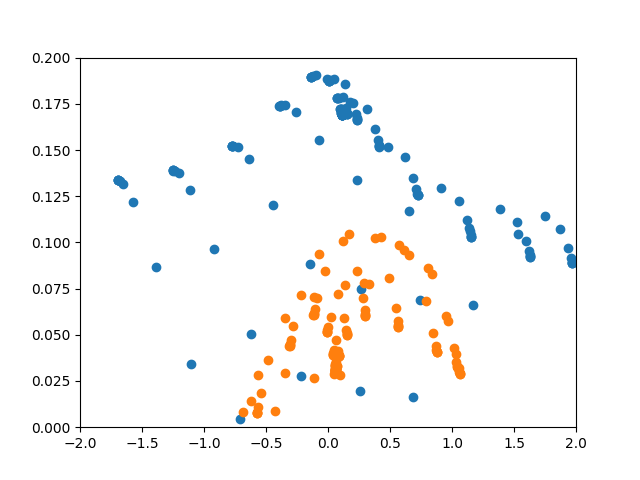

In [192]:
fig, ax = plt.subplots()
ax.scatter(ctrl_l_ratio, ctrl_l_r2)
ax.scatter(ctrl_lsw_ratio, ctrl_lsw_r2)
ax.set_ylim(0,.2)
ax.set_xlim(-2,2)
#ax.axhline(neg_asymps, xmin=0, xmax=.5, linestyle='--')
#ax.axhline(pos_asymps, xmin=.5, xmax=1, linestyle='--')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(-2.0, 2.0)

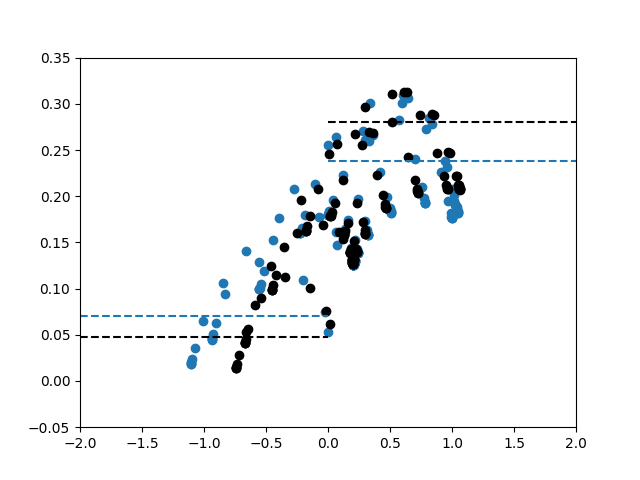

In [193]:
fig, ax = plt.subplots()
ax.scatter(sw_ratio, sw_r2, color='tab:blue')
ax.scatter(ctrl_sw_ratio, ctrl_sw_r2, color='black')
ax.axhline(sw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='tab:blue')
ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='tab:blue')
ax.axhline(csw_neg_asymps, xmin=0, xmax=.5, linestyle='--', color='black')
ax.axhline(csw_pos_asymps, xmin=.5, xmax=1, linestyle='--', color='black')
ax.set_ylim(-.05,.35)
ax.set_xlim(-2,2)